## CMPINF 2100

### REVIEW: Generate linear model data

We will review important assumpitons of linear models by generating data from a linear model

We will use a SINGLE imput that is LINEARLY related to the MEAN output or TREND

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Define the relationship

We will use a SINGLE continuous INPUT that is LINEARLY related to the TREND

$$\mu = \beta_0 + \beta_1 \times x $$

To generate the data, we need to specify the TRUE INTERCEPT and the TRUE SLOPE. We then must calculate the TREND or AVERAGE OUTPUT for a GIVEN INPUT value. Then we will randomly generate OUTPUT observations around the TREND using a Gaussian random number generator

## Visualize behavior

We must calculat the TREND and so we must SPECIFY the TRUE coefficient values

In [59]:
my_intercept = 0.25
my_slope = -1.5

Create a data set of INPUT values to support VISUALIZE behavior

In [60]:
df_viz = pd.DataFrame({'x': np.linspace(-3.5, 3.5, num=101)})

In [61]:
df_viz

,x
0,-3.50
1,-3.43
2,-3.36
3,-3.29
4,-3.22
...,...
96,3.22
97,3.29
98,3.36
99,3.43


Calculate the TREND or AVERAGE OUTPUT **GIVEN** the INPUT!!!

In [62]:
df_viz['trend'] = my_intercept + my_slope * df_viz.x

In [63]:
df_viz

,x,trend
0,-3.50,5.500
1,-3.43,5.395
2,-3.36,5.290
3,-3.29,5.185
4,-3.22,5.080
...,...,...
96,3.22,-4.580
97,3.29,-4.685
98,3.36,-4.790
99,3.43,-4.895


Let's visualize the TREND with respect to the INPUT as a LINE CHART

In [64]:
sns.set_style('whitegrid')

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


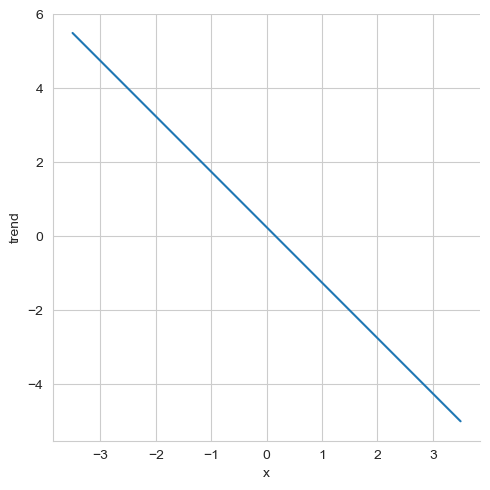

In [65]:
sns.relplot( data = df_viz, x='x', y='trend', kind='line')
plt.show()

This week we will make more figures in matplotlib rather than Seaborn. Let's make the same line chart in matplotlib

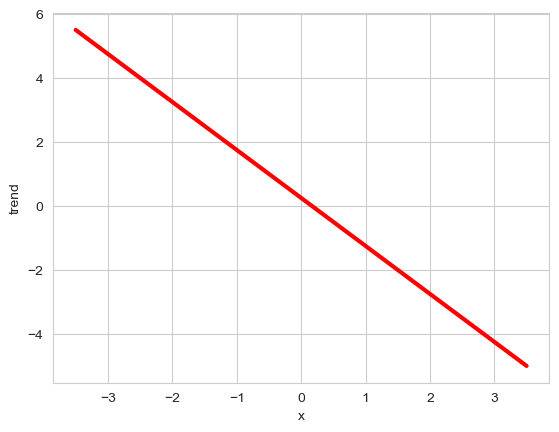

In [66]:
fig, ax = plt.subplots()

ax.plot(df_viz.x, df_viz.trend, color='r', linewidth=3 )
ax.set_xlabel('x')
ax.set_ylabel('trend')

plt.show()

We will now visualize the VARIATION around the TREND. Or, we will visualize the UNCERTAINTY of a single ouput measurement around the average output!!!

The LIKELYHOOD of an OUTPUT around the TREND is a GAUSSIAN distribution. The variatinon of a Gaussian is specified by the STANDARD DEVIATION or SIGMA

We need to specify the SIGMA that controls the level of variation around the trend

In [67]:
my_sigma = 1.25

Last week we RANDOMLY generate MANY replications of output around the trend to show the constant variation around the trend

This week, we will summarize that level of variation using **RIBBONS**

RIBBONS are defined by LOWER and UPPER BOUNDS that correspond to the LOWER  and UPPER BOUNDS of INTERVALS.

Because the linear model has a GAUSSIAN likelihood or distribution, the UNCERTAINTY can be easily summarized as the number of standard deviations around the mean

We will use the $\pm1 \sigma $ and the $\pm2 \sigma$ intervals around the mean. These correspond to the 68% and the 95% uncertainity intervals

In [68]:
df_viz['obs_lwr_68'] = df_viz.trend - my_sigma
df_viz['obs_upr_68'] = df_viz.trend + my_sigma

In [69]:
df_viz['obs_lwr_95'] = df_viz.trend - 2 * my_sigma
df_viz['obs_upr_95'] = df_viz.trend + 2 * my_sigma

In [70]:
df_viz

,x,trend,obs_lwr_68,obs_upr_68,obs_lwr_95,obs_upr_95
0,-3.50,5.500,4.250,6.750,3.000,8.000
1,-3.43,5.395,4.145,6.645,2.895,7.895
2,-3.36,5.290,4.040,6.540,2.790,7.790
3,-3.29,5.185,3.935,6.435,2.685,7.685
4,-3.22,5.080,3.830,6.330,2.580,7.580
...,...,...,...,...,...,...
96,3.22,-4.580,-5.830,-3.330,-7.080,-2.080
97,3.29,-4.685,-5.935,-3.435,-7.185,-2.185
98,3.36,-4.790,-6.040,-3.540,-7.290,-2.290
99,3.43,-4.895,-6.145,-3.645,-7.395,-2.395


Visualize the UNCERTAINTY or LEVEL of VARIATION using RIBBONS

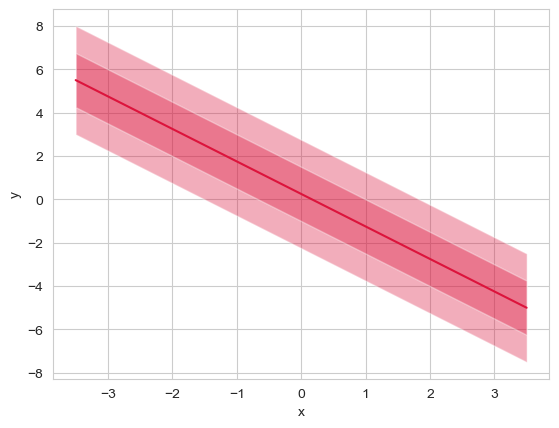

In [71]:
fig, ax = plt.subplots()

# True trend
ax.plot(df_viz.x, df_viz.trend, color='crimson', linewidth=1.5)

# True variation around the TREND - showing 2 intervals
# 2 sigma interval
ax.fill_between( df_viz.x, df_viz.obs_lwr_95, df_viz.obs_upr_95, facecolor='crimson', alpha=0.35)

# 1 sigma interval
ax.fill_between( df_viz.x, df_viz.obs_lwr_68, df_viz.obs_upr_68, facecolor='crimson', alpha=0.35)

# set labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# show the plot

plt.show()

## Generate random output data

Generate a small number of random output observations at specific input values

For simplicity, let's treat the input as NOT random. The input will have values UNIFORMALY spread between lower and upper bound.

Specifically let's use 9 input locations between -3 and 3

In [72]:
df = pd.DataFrame({'x': np.linspace(-3, 3, num=9)})

In [73]:
df

,x
0,-3.00
1,-2.25
2,-1.50
3,-0.75
4,0.00
5,0.75
6,1.50
7,2.25
8,3.00


Next, we need to calculate the MEAN OUPUT or TREND **GIVEN** the input values

In [74]:
df['trend'] = my_intercept + my_slope * df.x

In [75]:
df

,x,trend
0,-3.00,4.750
1,-2.25,3.625
2,-1.50,2.500
3,-0.75,1.375
4,0.00,0.250
5,0.75,-0.875
6,1.50,-2.000
7,2.25,-3.125
8,3.00,-4.250


The OUTPUT are RANDOMLY distributed around the MEAN as a GAUSSIAN distribution.

In [76]:
rg = np.random.default_rng(2100)

In [77]:
df['y'] = rg.normal( loc = df.trend, scale = my_sigma, size=df.shape[0])

In [78]:
df

,x,trend,y
0,-3.00,4.750,6.030315
1,-2.25,3.625,1.457911
2,-1.50,2.500,2.388383
3,-0.75,1.375,0.007815
4,0.00,0.250,0.651244
5,0.75,-0.875,-2.254007
6,1.50,-2.000,-2.969992
7,2.25,-3.125,-3.537097
8,3.00,-4.250,-6.063282


Visualize the randomly generated output around the TREND

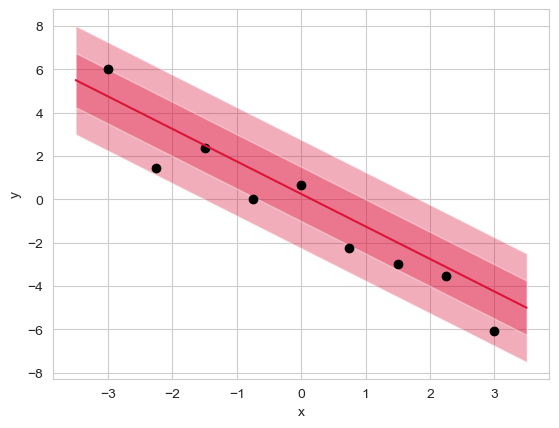

In [79]:
fig, ax = plt.subplots()

# True trend
ax.plot(df_viz.x, df_viz.trend, color='crimson', linewidth=1.5)

# True variation around the TREND - showing 2 intervals
# 2 sigma interval
ax.fill_between( df_viz.x, df_viz.obs_lwr_95, df_viz.obs_upr_95, facecolor='crimson', alpha=0.35)

# 1 sigma interval
ax.fill_between( df_viz.x, df_viz.obs_lwr_68, df_viz.obs_upr_68, facecolor='crimson', alpha=0.35)

# include the randomly generated small data set as a scatter plot
ax.scatter(df.x, df.y, color='k')

# set labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# show the plot

plt.show()

Let's save this small data set so we can ultimately FIT models to it

But, for book keeping purposes let's store the TRUE coefficients and SIGMA that generated data

In [80]:
df['true_intercept'] = my_intercept

In [81]:
df['true_slope'] = my_slope

In [82]:
df['true_sigma'] = my_sigma

In [83]:
df

,x,trend,y,true_intercept,true_slope,true_sigma
0,-3.00,4.750,6.030315,0.25,-1.5,1.25
1,-2.25,3.625,1.457911,0.25,-1.5,1.25
2,-1.50,2.500,2.388383,0.25,-1.5,1.25
3,-0.75,1.375,0.007815,0.25,-1.5,1.25
4,0.00,0.250,0.651244,0.25,-1.5,1.25
5,0.75,-0.875,-2.254007,0.25,-1.5,1.25
6,1.50,-2.000,-2.969992,0.25,-1.5,1.25
7,2.25,-3.125,-3.537097,0.25,-1.5,1.25
8,3.00,-4.250,-6.063282,0.25,-1.5,1.25


Save the dataframe to a CSV file

In [84]:
df.to_csv('week_10_linear_data.csv', index=False)

Let's read the data to confirm we saved it correctly

In [85]:
pd.read_csv('week_10_linear_data.csv')

,x,trend,y,true_intercept,true_slope,true_sigma
0,-3.00,4.750,6.030315,0.25,-1.5,1.25
1,-2.25,3.625,1.457911,0.25,-1.5,1.25
2,-1.50,2.500,2.388383,0.25,-1.5,1.25
3,-0.75,1.375,0.007815,0.25,-1.5,1.25
4,0.00,0.250,0.651244,0.25,-1.5,1.25
5,0.75,-0.875,-2.254007,0.25,-1.5,1.25
6,1.50,-2.000,-2.969992,0.25,-1.5,1.25
7,2.25,-3.125,-3.537097,0.25,-1.5,1.25
8,3.00,-4.250,-6.063282,0.25,-1.5,1.25
